# **Covid-19 Vaccine Sentiment Analysis**

**Import Libraries**

In [435]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import datetime
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from nltk.sentiment.vader import SentimentIntensityAnalyzer   # VADER sentiment analyzer
from wordcloud import WordCloud, STOPWORDS
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report, confusion_matrix)

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**Load the Dataset**

In [436]:
from google.colab import files
uploaded = files.upload()

Saving vaccination_tweets.csv to vaccination_tweets (8).csv


## **Data Exploration**

In [437]:
data = pd.read_csv('vaccination_tweets.csv')
data.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


In [438]:
data.columns.to_list()

['id',
 'user_name',
 'user_location',
 'user_description',
 'user_created',
 'user_followers',
 'user_friends',
 'user_favourites',
 'user_verified',
 'date',
 'text',
 'hashtags',
 'source',
 'retweets',
 'favorites',
 'is_retweet']

In [439]:
print(f'The Dataset contains {data.shape[0]} rows and {data.shape[1]} columns')

The Dataset contains 11020 rows and 16 columns


In [440]:
data.isnull().sum()

,0
id,0
user_name,0
user_location,2270
user_description,680
user_created,0
user_followers,0
user_friends,0
user_favourites,0
user_verified,0
date,0


In [441]:
print(data.duplicated().sum())   # Finding duplicate records

0


In [442]:
data[data['source'].isna()]   # Visualizing the row where 'source' column is NULL

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
1838,1344269125011562498,RoboForex Official,NaN,International broker that offers to trade 8 ty...,2020-11-16 16:22:43,84,1,20,False,2020-12-30 13:08:29,💉 #Pfizer and #BioNTech were the first to get ...,"['Pfizer', 'BioNTech']",NaN,0,0,False


In [443]:
# datatypes of columns that are 'object'
data.select_dtypes(include='object').columns.to_list()

['user_name',
 'user_location',
 'user_description',
 'user_created',
 'date',
 'text',
 'hashtags',
 'source']

In [444]:
# datatypes of columns that are 'int' integer
data.select_dtypes(include='int').columns.tolist()

['id',
 'user_followers',
 'user_friends',
 'user_favourites',
 'retweets',
 'favorites']

In [445]:
# datatypes of columns that are 'bool' boolean
data.select_dtypes(include='bool').columns.to_list()

['user_verified', 'is_retweet']

## **Data Cleaning**

In [446]:
# Dropping rows that contains NULL values
data = data.dropna().reset_index(drop=True)
data.isna().sum()

,0
id,0
user_name,0
user_location,0
user_description,0
user_created,0
user_followers,0
user_friends,0
user_favourites,0
user_verified,0
date,0


In [447]:
# Data Type Correction
data['date'] = pd.to_datetime(
    data['date']
)
data['user_created'] = pd.to_datetime(
    data['user_created']
)
data[['date','user_created']].dtypes

,0
date,datetime64[ns]
user_created,datetime64[ns]




**Cleaning Function**

In [448]:
def clean_tweet(text):
  text = text.lower()   # Converting tweet to lowercase
  text = re.sub(r'http\S+|www\S+|https\S+','',text)  # Remove URLs
  text = re.sub(r'@\w+','',text)  # Remove @ mentions
  text = re.sub(r'#','',text)  # Remove # hashtags
  text = re.sub(r'\brt\b','',text)  # Remove RT markers
  text = re.sub(r'[^a-z0-9\s]','',text) # Remove non-alphanumeric characters
  text = re.sub(r'\s+',' ',text)  # Remove multiple spaces
  text = text.strip()    # Remove leading and trailing spaces
  tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
  return ' '.join(tokens) # Removing stopwords and lemmatizing

data['clean_text'] = data['text'].apply(clean_tweet)


In [449]:
data[['text','clean_text']].head()

,text,clean_text
0,Same folks said daikon paste could treat a cyt...,folk said daikon paste could treat cytokine st...
1,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,coronavirus sputnikv astrazeneca pfizerbiontec...
2,it is a bit sad to claim the fame for success ...,bit sad claim fame success vaccination patriot...
3,#CovidVaccine \n\nStates will start getting #C...,covidvaccine state start getting covid19vaccin...
4,"while deaths are closing in on the 300,000 mar...",death closing 300000 mark million people wait ...


In [450]:
# Visualizing diff between 'old text' and new 'clean text' from a random row
print(data.iloc[54]['text'])
print(data.iloc[54]['clean_text'])

Half way there #COVID19 #CovidVaccine #vaccination #Pfizervaccine #PfizerBioNTech https://t.co/fQOSDAGOWD
half way covid19 covidvaccine vaccination pfizervaccine pfizerbiontech


**Initiaizing VADER**

In [451]:
sia = SentimentIntensityAnalyzer()

In [452]:
# Calculating VADER sentiment scores for every cleaned tweet
sentiment_scores = data['clean_text'].apply(sia.polarity_scores)
data['positive_score'] = sentiment_scores.apply(lambda x: x['pos'])  # Extracting the positive sentiment probability
data['neutral_score'] = sentiment_scores.apply(lambda x: x['neu'])   # Extracting the neutral sentiment probability
data['negative_score'] = sentiment_scores.apply(lambda x: x['neg'])  # Extracting the negative sentiment probability
data['compound_score'] = sentiment_scores.apply(lambda x: x['compound']) # Extracting VADER's overall compound sentiment score

In [453]:
# Creating Sentiment Classes
def classify_sentiment(score):
  if score >= 0.05:
    return 'Positive'
  elif score <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'   # scores btw -0.05 to 0.05 are considered neutral

# Applying the classification function to very tweet
data['sentiment'] = data['compound_score'].apply(classify_sentiment)
data['sentiment'].value_counts()

,count
sentiment,
Neutral,2947
Positive,2595
Negative,925


In [454]:
# Visualizing our dataset after addition of some more columns
data.head(2)

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,source,retweets,favorites,is_retweet,clean_text,positive_score,neutral_score,negative_score,compound_score,sentiment
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,...,Twitter for Android,0,0,False,folk said daikon paste could treat cytokine st...,0.252,0.748,0.0,0.4019,Positive
1,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,...,Twitter for Android,0,0,False,coronavirus sputnikv astrazeneca pfizerbiontec...,0.167,0.833,0.0,0.2500,Positive


## **Exploratory Data Analysis**

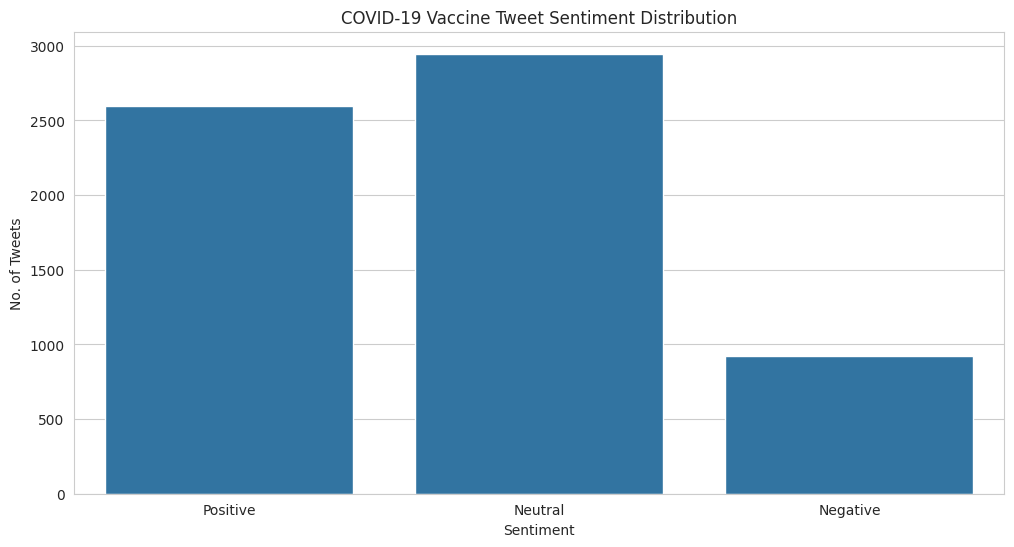

<Figure size 1200x800 with 0 Axes>

In [455]:
sns.countplot(
    data=data,
    x='sentiment',
    order=['Positive','Neutral','Negative']
)
plt.title('COVID-19 Vaccine Tweet Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('No. of Tweets')
plt.figure(figsize=(12, 8))
plt.show()

In [456]:
# Sentiment Percentages
sentiment_percentage = (
    data['sentiment'].value_counts(normalize=True).mul(100).round(2)
)
sentiment_percentage

,proportion
sentiment,
Neutral,45.57
Positive,40.13
Negative,14.30


In [457]:
numeric_columns = ['user_followers',
                   'user_friends',
                   'user_favourites',
                   'retweets',
                   'favorites']
display(data[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
user_followers,6467.0,49200.725375,362746.821593,0.0,169.0,628.0,2944.5,13714928.0
user_friends,6467.0,1317.237668,3106.099198,0.0,210.5,549.0,1416.0,103226.0
user_favourites,6467.0,14820.703881,37836.005098,0.0,492.5,2753.0,12186.0,854011.0
retweets,6467.0,1.432813,11.842517,0.0,0.0,0.0,1.0,678.0
favorites,6467.0,8.229782,48.227562,0.0,0.0,1.0,4.0,1979.0


In [458]:
engagement_summary = data.groupby('sentiment')[['retweets','favorites']].mean().sort_values('favorites', ascending=False)
display(engagement_summary)

,retweets,favorites
sentiment,,
Positive,1.273603,10.905202
Neutral,1.498812,6.860197
Negative,1.669189,5.087568


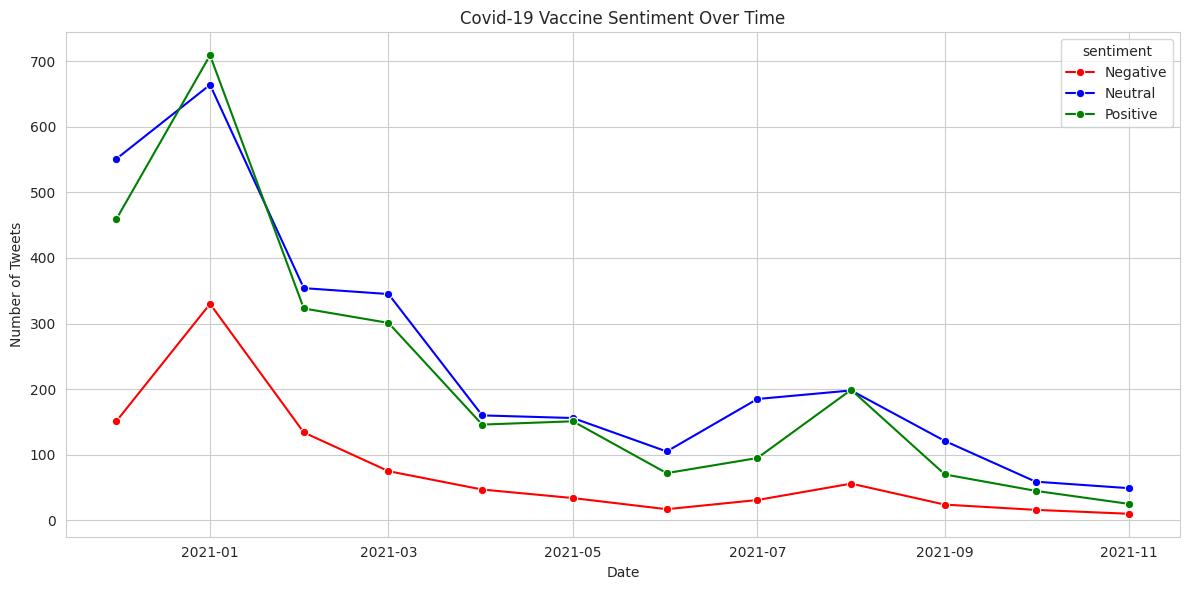

In [459]:
# Visualization of Sentiment over Time
monthly_sentiment = (
    data.dropna(subset=['date'])
    .groupby([data['date'].dt.to_period('M'), 'sentiment'])
    .size()
    .reset_index(name='tweet_count')
)  # Counting tweets for each sentiment category per month
monthly_sentiment['date'] = monthly_sentiment['date'].dt.to_timestamp()   # Converting monthly periods back to timestamps for line plot visualization

sns.lineplot(
    data=monthly_sentiment,
    x='date',
    y='tweet_count',
    hue='sentiment',  # Creates one line for each sentiment category
    marker='o',
    palette={
        'Positive':'green',
        'Negative':'red',
        'Neutral':'blue'
    }
)
plt.title('Covid-19 Vaccine Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

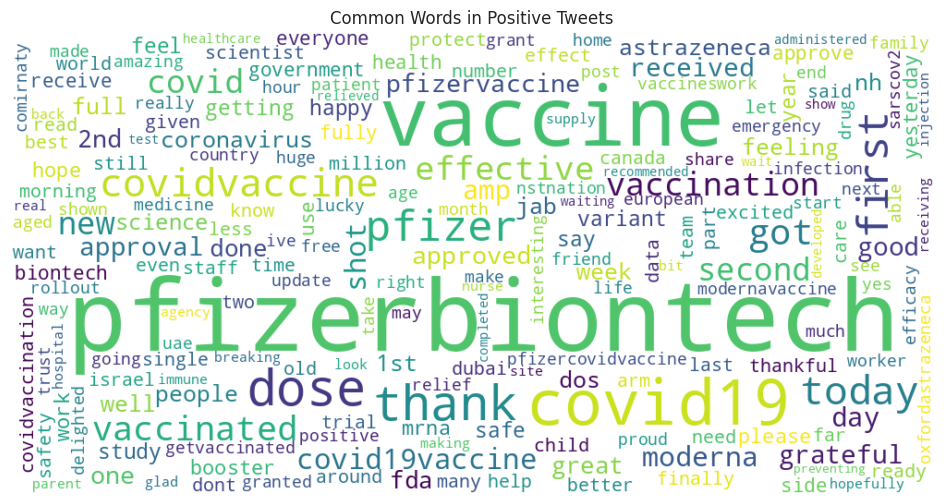

In [460]:
# Positive sentiment WordCloud
positive_text = ' '.join(
      data.loc[data['sentiment'] == 'Positive', 'clean_text' ]
  )  # Combining all positive tweets into one large text document
wordcloud_pos = WordCloud(
      width=1000,
      height=500,
      background_color='white',
      stopwords=STOPWORDS,
      collocations=False    # Prevents repeated words to avoid dominating wordcloud
  ).generate(positive_text)

plt.title('Common Words in Positive Tweets')
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.show()

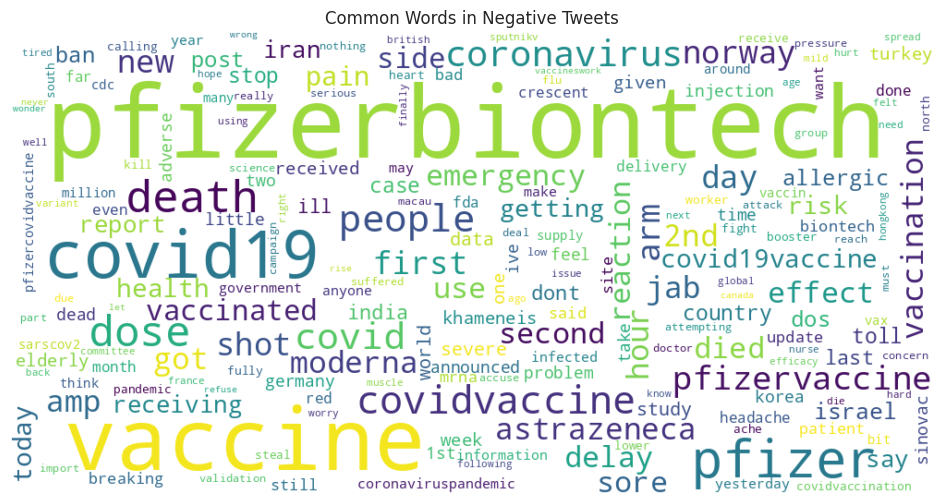

In [461]:
# Negative Sentiment WordCloud
negative_text = ' '.join(
    data.loc[data['sentiment'] == 'Negative', 'clean_text']
)
wordcloud_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS,
    collocations=False
).generate(negative_text)

plt.title('Common Words in Negative Tweets')
plt.axis('off')
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.show()

## **Model Building & Training**

In [462]:
x = data['clean_text']    # Independent Variable (Input)
y = data['sentiment']     # Dependent Variable (Target)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f'Training Samples: {len(x_train):,} & Training Labels {len(y_train):,}')
print(f'Testing Samples: {len(x_test):,} & Testing Labels {len(y_test):,}')

Training Samples: 5,173 & Training Labels 5,173
Testing Samples: 1,294 & Testing Labels 1,294


In [463]:
# TF-IDF Feature Engineering
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),  # Uses both individual and two-word combinations
    min_df=2,   # Removes extremely rare words
    max_df=0.95,   # Removes extremely common words
    sublinear_tf=True,    # Applies logartithmic term-frequency scaling
    max_features=30000   # Limits vocabulary size to 25,000 features
)

**Logistic Regression Model**

In [464]:
logistic_model = Pipeline([
    (
        'tfidf',
        tfidf
    ),   # Converting tweet text into TF-IDF numerical features

    (
        'classifier',
        LogisticRegression(
            max_iter=1000,   # iterations for model convergence
            class_weight='balanced',
            random_state=42
        )
    )

  ])
logistic_model.fit(x_train, y_train)   # Training complete TF-IDF logistic Regression Pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

**Naive Bayes Model**

In [465]:
naiveBayes_model = Pipeline([
    (
        'tfidf',
         tfidf
    ),
    (
        'classifier',
        MultinomialNB()    # Creating the Multinomial Naive Bayes classifier
    )
])
naiveBayes_model.fit(x_train, y_train)  # Training Naiye Bayes

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', MultinomialNB())])

**Linear Support Vector Machine**

In [466]:
svm_model = Pipeline([
    (
        'tfidf',
        tfidf
    ),
    (
        'classifier',
        LinearSVC(
            class_weight='balanced',
            random_state=42
        )   # Creating Linear SVM Classifier
    )
])
svm_model.fit(x_train, y_train)  # Training the linear SVM model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LinearSVC(class_weight='balanced', random_state=42))])

## **Model Evaluation**

In [467]:
def evaluate_model(model, x_test, y_test, model_name):
  predictions = model.predict(x_test)   # Generates predictions for unseen text tweets
  accuracy = accuracy_score(y_test, predictions)  # Calculating overall accuracy
  precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
  recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
  f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
  return {
      'Model':model_name,
      'Accuracy':accuracy,
      'Precision':precision,
      'Recall':recall,
      'F1-Score':f1
        }

In [468]:
models = [
    (logistic_model, 'Logistic Regression'),
    (naiveBayes_model, 'Multinomial Naive Bayes'),
    (svm_model, 'Linear SVM')
]
results = []

for model, model_name in models:
  result = evaluate_model(
      model,
      x_test,
      y_test,
      model_name
  )
  results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False,
)

print('Model Comparison:')
display(results_df.reset_index(drop=True))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.829212,0.828594,0.829212,0.826864
1,Logistic Regression,0.808346,0.812870,0.808346,0.808020
2,Multinomial Naive Bayes,0.755796,0.777822,0.755796,0.720313


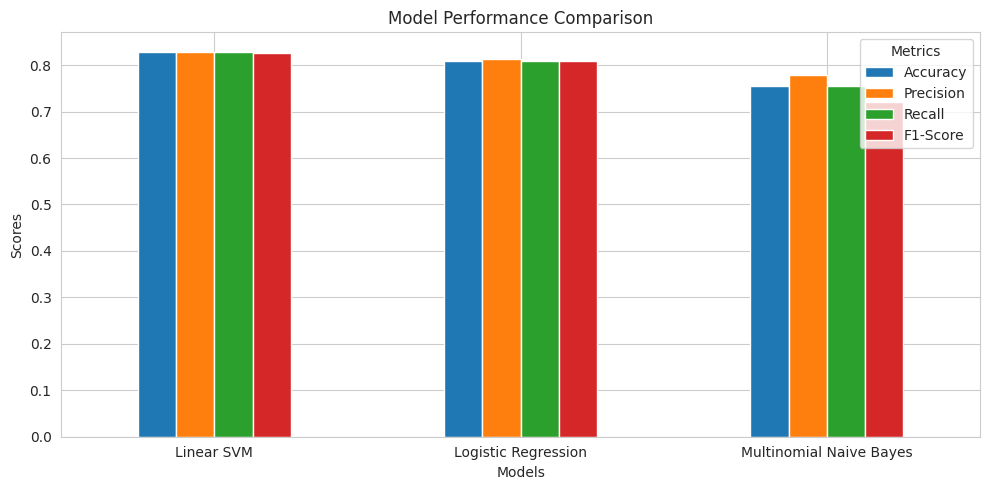

In [469]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend(title='Metrics')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [470]:
best_model_name = results_df.loc[
    results_df['F1-Score'].idxmax(),
    'Model'
]
best_model = None
for model, model_name in models:
  if model_name == best_model_name:
    best_model = model
    break
print(f'Best model Based on F1-Score: {best_model_name}')

Best model Based on F1-Score: Linear SVM


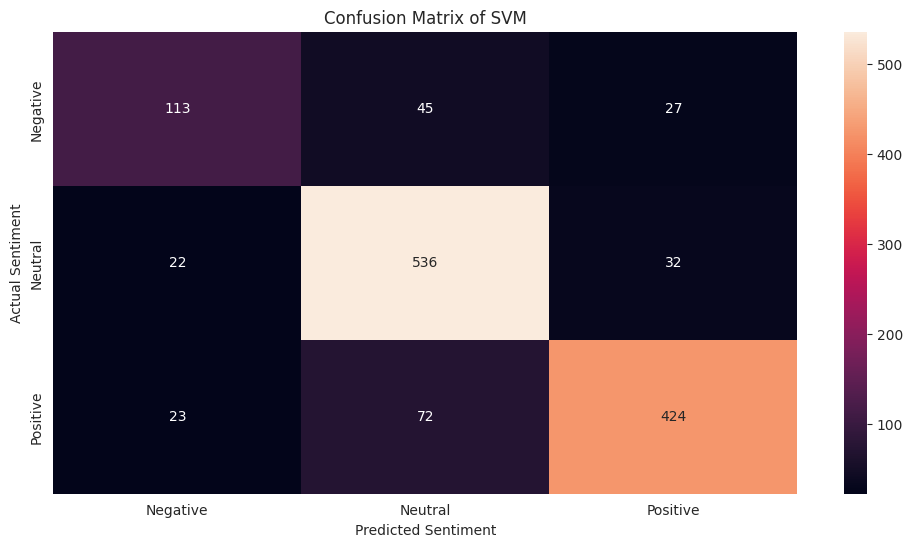

<Figure size 800x400 with 0 Axes>

In [471]:
# Confusion Matrix
best_predictions = best_model.predict(x_test)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=['Negative','Neutral','Positive']
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)
plt.title('Confusion Matrix of SVM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.figure(figsize=(8,4))
plt.tight_layout()
plt.show()

In [472]:
print('Classification Report:')
print(classification_report(y_test,
                      best_predictions,
                      zero_division=0))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.61      0.66       185
     Neutral       0.82      0.91      0.86       590
    Positive       0.88      0.82      0.85       519

    accuracy                           0.83      1294
   macro avg       0.80      0.78      0.79      1294
weighted avg       0.83      0.83      0.83      1294



**Error Analysis**

In [473]:
error_analysis = pd.DataFrame({
    'tweet':x_test,
    'Actual':y_test,
    'Predicted':best_predictions
})
errors = error_analysis[error_analysis['Actual'] != error_analysis['Predicted']]
print('Number of Errors: ',len(errors))
display(error_analysis.head())

Number of Errors:  221


,tweet,Actual,Predicted
4716,wato referred pfizerbiontech oxfordastrazeneca...,Neutral,Neutral
3592,covid19vaccine 2day version best medical histo...,Positive,Positive
1418,take covid19 second dose pfizerbiontech vaccin...,Positive,Negative
2305,fyi premier apparently coming notmypremier una...,Positive,Negative
6202,boosted pfizerbiontech 3rdshot,Positive,Positive


In [474]:
print(f'Number of Errors: {len(errors)}')
print(f'Error rate: {len(errors) / len(error_analysis) * 100:.2f}%')
print('\nSample misclassified tweets:')
print('Error breakdown (Actual → Predicted):')
print(pd.crosstab(errors['Actual'], errors['Predicted'], margins=True))

Number of Errors: 221
Error rate: 17.08%

Sample misclassified tweets:
Error breakdown (Actual → Predicted):
Predicted  Negative  Neutral  Positive  All
Actual                                     
Negative          0       45        27   72
Neutral          22        0        32   54
Positive         23       72         0   95
All              45      117        59  221


**Prediction Function**

In [475]:
def predict_tweet(tweet):
  cleaned = clean_tweet(tweet)
  prediction = best_model.predict([cleaned])[0]
  return prediction

examples = ['Just got my Pfizer vaccine, feeling great and hopeful!',
    'The side effects of this vaccine are bad, never again.',
    'Government announced new vaccine distribution plan two days ago.']
for i in examples:
  print(f'Tweet: {i}')
  print(f'Predicted: {predict_tweet(i)}')

Tweet: Just got my Pfizer vaccine, feeling great and hopeful!
Predicted: Positive
Tweet: The side effects of this vaccine are bad, never again.
Predicted: Negative
Tweet: Government announced new vaccine distribution plan two days ago.
Predicted: Neutral


Try it yourself!!

In [ ]:
n = input('Enter your tweet for prediction: ')
print(f'Tweet: {n}')
print(f'Preciction: {predict_tweet(n)}')

# **COVID-19 Vaccine Sentiment Analysis**
## **Project Summary**

This project performs **COVID-19 Vaccine Sentiment Analysis** using Natural Language Processing (NLP) and Machine Learning. The goal is to analyze vaccine-related tweets and classify them into **Positive, Neutral, or Negative** sentiment categories. The workflow includes data exploration, tweet cleaning, VADER sentiment labeling, exploratory analysis, TF-IDF feature extraction, multiple machine-learning models, evaluation, error analysis, and prediction of sentiment for new tweets.

---

## **Dataset Overview**

The project uses the **`vaccination_tweets.csv`** dataset, which initially contains **11,020 tweets and 16 columns** with tweet-level, user-level, and engagement information.

| Dataset / Feature        | Description                              |
| ------------------------ | ---------------------------------------- |
| `vaccination_tweets.csv` | COVID-19 vaccine-related Twitter dataset |
| Initial records          | 11,020                                   |
| Initial columns          | 16                                       |
| Records after cleaning   | 6,467                                    |
| `date`                   | Tweet publication date                   |
| `user_created`           | User account creation date               |
| `text`                   | Tweet content                            |
| `hashtags`               | Hashtags associated with the tweet       |
| `user_location`          | User location                            |
| `followers`              | Number of followers                      |
| `friends`                | Number of friends                        |
| `retweets`               | Number of retweets                       |
| `favorites`              | Number of favorites                      |
| `sentiment`              | Positive, Neutral, or Negative           |

The dataset contains **0 duplicate records**. Missing values were removed using `dropna()`, reducing the dataset from **11,020 to 6,467 tweets**.

---

## **Project Workflow**

### 1. Data Loading and Exploration

The dataset is loaded using Pandas and examined through:

* Dataset shape
* Column names
* Data types
* Missing-value analysis
* Duplicate checking
* Descriptive statistics
* Sentiment distribution

The `date` and `user_created` columns are converted into proper Pandas datetime formats to support time-based analysis.

### 2. Data Cleaning

A custom `clean_tweet()` function is used to prepare tweets for sentiment analysis.

The preprocessing includes:

* Converting text to lowercase
* Removing URLs
* Removing Twitter mentions
* Removing `#` symbols while keeping hashtag words
* Removing `RT`
* Removing unwanted characters
* Removing extra whitespace

For example:

> `#PfizerVaccine https://t.co/...`

is transformed into a cleaner representation such as:

> `pfizervaccine`

Keeping the hashtag word is useful because hashtags can contain important information about the topic or sentiment of a tweet.

### 3. VADER Sentiment Analysis

The cleaned tweets are analyzed using **VADER (Valence Aware Dictionary and sEntiment Reasoner)**.

VADER generates:

* Positive score
* Neutral score
* Negative score
* Compound score

The compound score is then converted into sentiment labels:

| Compound Score  | Sentiment |
| --------------- | --------- |
| `>= 0.05`       | Positive  |
| `<= -0.05`      | Negative  |
| `-0.05 to 0.05` | Neutral   |

This produces the target sentiment labels used later for machine learning.

### 4. Sentiment Distribution

After VADER labeling, the 6,467 tweets are distributed as follows:

| Sentiment |    Tweets | Percentage |
| --------- | --------: | ---------: |
| Neutral   |     2,947 |     45.57% |
| Positive  |     2,595 |     40.13% |
| Negative  |       925 |     14.30% |
| **Total** | **6,467** |   **100%** |



### 5. Engagement and Time-Based Analysis

The project explores engagement metrics such as:

* Followers
* Friends
* User favorites
* Retweets
* Tweet favorites

Average engagement by sentiment was also analyzed:

| Sentiment | Avg. Retweets | Avg. Favorites |
| --------- | ------------: | -------------: |
| Positive  |          1.27 |          10.91 |
| Neutral   |          1.50 |           6.86 |
| Negative  |          1.67 |           5.09 |

Negative tweets received the highest average number of retweets, while positive tweets had the highest average number of favorites.

The project also analyzes **sentiment over time by month**, helping visualize how positive, neutral, and negative vaccine-related discussions changed throughout the dataset period.

### 6. Word Cloud Analysis

Separate word clouds are generated for:

* Positive tweets
* Negative tweets

This provides a visual representation of frequently occurring words within different sentiment categories.

### 7. Train/Test Split

For machine learning, the cleaned tweet text is used as the input and VADER sentiment as the target:

* **Input:** `clean_text`
* **Target:** `sentiment`

The dataset is split using:

* **80% training data**
* **20% testing data**
* `random_state=42`
* `stratify=y`

| Dataset   |   Samples |
| --------- | --------: |
| Training  |     5,173 |
| Testing   |     1,294 |
| **Total** | **6,467** |



---

## **Model Training and Building**

### TF-IDF Feature Extraction

Since machine-learning models cannot directly process raw text, the tweets are converted into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

The configuration uses:

* **Unigrams:** individual words
* **Bigrams:** two-word combinations
* `min_df=2`
* `max_df=0.95`
* `sublinear_tf=True`
* `max_features=30000`

Using both unigrams and bigrams allows the model to capture individual words as well as phrases such as:

> `covid vaccine`

### Models Trained

Three machine-learning classifiers are trained:

* **Logistic Regression**
* **Multinomial Naive Bayes**
* **Linear SVM**

Class balancing is applied to Logistic Regression and Linear SVM to account for differences in sentiment-class frequency.

---

## **Model Performance**

The models were evaluated using **Accuracy, Precision, Recall, and F1-Score**.

| Model                   |   Accuracy |  Precision |     Recall |   F1-Score |
| ----------------------- | ---------: | ---------: | ---------: | ---------: |
| **Linear SVM**          | **82.92%** | **82.86%** | **82.92%** | **82.69%** |
| Logistic Regression     |     80.83% |     81.29% |     80.83% |     80.80% |
| Multinomial Naive Bayes |     75.58% |     77.78% |     75.58% |     72.03% |

### Best Model

**Linear SVM** achieved the highest F1-score and was therefore selected as the final model.

> **Accuracy: 82.92%**
> **F1-Score: 82.69%**

---

## **Detailed Linear SVM Evaluation**

| Sentiment | Precision | Recall | F1-Score | Support |
| --------- | --------: | -----: | -------: | ------: |
| Negative  |      0.72 |   0.61 |     0.66 |     185 |
| Neutral   |      0.82 |   0.91 |     0.86 |     590 |
| Positive  |      0.88 |   0.82 |     0.85 |     519 |

The model performs best on **Neutral sentiment**, achieving a recall of **91%**.

Positive sentiment has the highest precision at **88%**, meaning positive predictions are generally reliable.

The weakest class is **Negative sentiment**, with:

* Precision: **72%**
* Recall: **61%**
* F1-score: **66%**

This indicates that the model has more difficulty identifying negative vaccine-related tweets.

---

## **Error Analysis**

The Linear SVM produced **221 incorrect predictions out of 1,294 test tweets**, corresponding to an error rate of approximately **17.08%**.

The notebook also displays incorrectly classified tweets to help understand where the model struggles.

---

### **New Tweet Prediction**

A custom `predict_tweet()` function allows the trained Linear SVM model to classify new tweets.

Example inputs include:

```text
"Just got my Pfizer vaccine, feeling great and hopeful!"
```

**Prediction:** Positive

```text
"The side effects of this vaccine are bad, never again."
```

**Prediction:** Negative

```text
"Government announced new vaccine distribution plan two days ago."
```

**Prediction:** Neutral

This demonstrates how the trained model can be used for sentiment prediction on previously unseen tweets.


---

## **Conclusion**

The COVID-19 Vaccine Sentiment Analysis project demonstrates a complete **NLP and Machine Learning pipeline** for analyzing public sentiment in vaccine-related tweets. After cleaning the dataset, VADER was used to generate sentiment labels, followed by TF-IDF feature extraction and training of three classification algorithms.

Among the tested models, **Linear SVM performed the best**, achieving **82.92% accuracy and 82.69% F1-score**. The model performed particularly well for Neutral and Positive sentiment, while Negative sentiment remained more challenging with a recall of **61%**.


### **🙋‍♂️ Author**

Made by Hashir khan  
Feel free to ⭐ the repo if you found it helpful!